# Exp10.0 — Airborne-motion ablation

Analysis-only notebook for finalized Exp10.0 artifacts. Training and probes are run by the Slurm workflow.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    p = start.resolve()
    for candidate in (p, *p.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'scripts').is_dir():
            return candidate
    raise RuntimeError('writingRing repo root not found')

repo = find_repo_root()
root = repo / 'notebooks' / 'artifacts' / 'experiment_10_0_airborne_motion_ablation' / 'a2_cross_user_5fold_v1'
manifest = json.loads((root / 'manifest.json').read_text())
manifest


{'architecture': '234x234',
 'architecture_shifts': [[2, 3, 4], [2, 3, 4]],
 'combined_actions': [0, 1],
 'expected_run_count': 45,
 'experiment_id': 'experiment_10_0_airborne_motion_ablation',
 'interpretation': {'D0_minus_D1': 'explicit airborne/reposition timestep evidence',
  'D0_minus_D2': 'total effect of removing airborne acceleration from representation',
  'D1_minus_D2': 'airborne acceleration influence on writing-period representation through encoder temporal context'},
 'model_seeds': [11, 23, 37],
 'paired_contrasts': ['D0_minus_D1', 'D1_minus_D2', 'D0_minus_D2'],
 'primary_metric': 'native_test_balanced_accuracy',
 'primary_outputs': ['run_metrics.csv',
  'variant_split_level.csv',
  'variant_summary.csv',
  'paired_variant_deltas.csv',
  'paired_variant_split_deltas.csv',
  'paired_variant_summary.csv',
  'probe_runs.csv',
  'probe_split_level.csv',
  'probe_summary.csv',
  'probe_paired_variant_deltas.csv',
  'probe_paired_variant_split_deltas.csv',
  'probe_paired_varia

In [2]:
variant_summary = pd.read_csv(root / 'variant_summary.csv')
paired_summary = pd.read_csv(root / 'paired_variant_summary.csv')
variant_summary


,variant,native_test_balanced_accuracy_count,native_test_balanced_accuracy_mean,native_test_balanced_accuracy_std,lif_test_balanced_accuracy_count,lif_test_balanced_accuracy_mean,lif_test_balanced_accuracy_std,native_test_action0_balanced_accuracy_count,native_test_action0_balanced_accuracy_mean,native_test_action0_balanced_accuracy_std,native_test_action1_balanced_accuracy_count,native_test_action1_balanced_accuracy_mean,native_test_action1_balanced_accuracy_std,lif_test_action0_balanced_accuracy_count,lif_test_action0_balanced_accuracy_mean,lif_test_action0_balanced_accuracy_std,lif_test_action1_balanced_accuracy_count,lif_test_action1_balanced_accuracy_mean,lif_test_action1_balanced_accuracy_std
0,masked_accel_reencode,5,0.440126,0.083827,5,0.376511,0.073400,5,0.414392,0.088489,5,0.470589,0.090351,5,0.363490,0.079831,5,0.393525,0.070916
1,original,5,0.454377,0.083087,5,0.411239,0.080652,5,0.431155,0.094959,5,0.480807,0.081099,5,0.395955,0.080774,5,0.430734,0.089089
2,postencode_mask,5,0.478075,0.070013,5,0.413220,0.065957,5,0.439381,0.058626,5,0.521204,0.091483,5,0.392456,0.070829,5,0.437070,0.075251


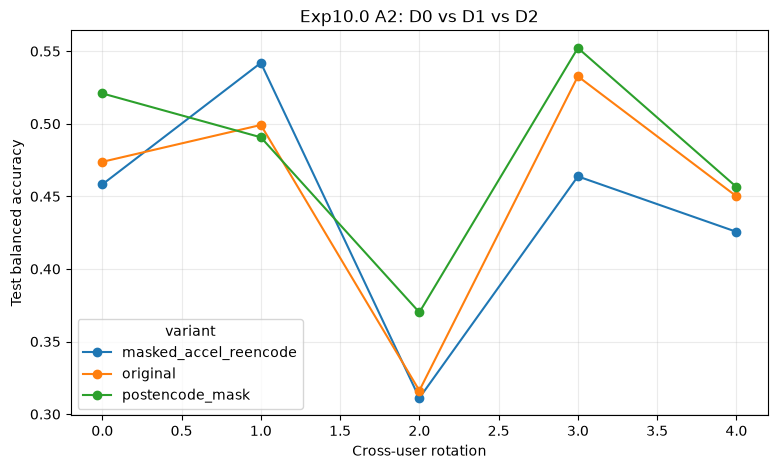

In [3]:
split_level = pd.read_csv(root / 'variant_split_level.csv')
pivot = split_level.pivot(index='rotation', columns='variant', values='native_test_balanced_accuracy')
ax = pivot.plot(marker='o', figsize=(9, 5))
ax.set_ylabel('Test balanced accuracy')
ax.set_xlabel('Cross-user rotation')
ax.set_title('Exp10.0 A2: D0 vs D1 vs D2')
ax.grid(True, alpha=0.25)
plt.show()


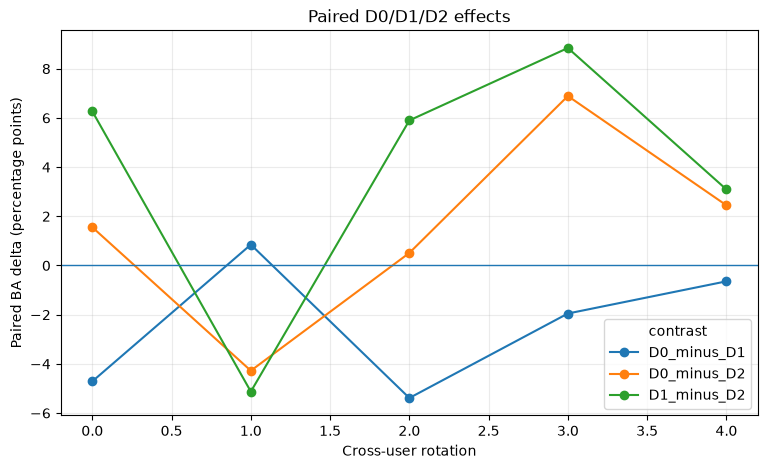

In [4]:
paired_split = pd.read_csv(root / 'paired_variant_split_deltas.csv')
delta_col = 'native_test_balanced_accuracy_delta'
delta = paired_split.pivot(index='rotation', columns='contrast', values=delta_col)
ax = (100 * delta).plot(marker='o', figsize=(9, 5))
ax.axhline(0, linewidth=1)
ax.set_ylabel('Paired BA delta (percentage points)')
ax.set_xlabel('Cross-user rotation')
ax.set_title('Paired D0/D1/D2 effects')
ax.grid(True, alpha=0.25)
plt.show()


In [5]:
probe_split = pd.read_csv(root / 'probe_split_level.csv')
core = [
    'input__events__fixed250_count',
    'l1__spike__fixed250_count',
    'l2__spike__fixed250_count',
]
probe_core = probe_split[probe_split.probe.isin(core)].copy()
probe_core.groupby(['variant', 'probe']).test_balanced_accuracy.agg(['mean', 'std'])


mean       std
variant               probe                                            
masked_accel_reencode input__events__fixed250_count  0.564079  0.057275
                      l1__spike__fixed250_count      0.568665  0.077073
                      l2__spike__fixed250_count      0.576879  0.076243
original              input__events__fixed250_count  0.595896  0.045161
                      l1__spike__fixed250_count      0.563131  0.060546
                      l2__spike__fixed250_count      0.576147  0.082011
postencode_mask       input__events__fixed250_count  0.627677  0.030041
                      l1__spike__fixed250_count      0.573466  0.087888
                      l2__spike__fixed250_count      0.593947  0.083706

In [6]:
probe_delta_summary = pd.read_csv(root / 'probe_paired_variant_summary.csv')
probe_delta_summary[probe_delta_summary.probe.isin(core)]


,contrast,probe,count,mean,std
3,D0_minus_D1,input__events__fixed250_count,5,-0.031781,0.022500
4,D1_minus_D2,input__events__fixed250_count,5,0.063598,0.047273
5,D0_minus_D2,input__events__fixed250_count,5,0.031817,0.047242
33,D0_minus_D1,l1__spike__fixed250_count,5,-0.010335,0.034213
34,D1_minus_D2,l1__spike__fixed250_count,5,0.004800,0.027869
35,D0_minus_D2,l1__spike__fixed250_count,5,-0.005534,0.040622
63,D0_minus_D1,l2__spike__fixed250_count,5,-0.017799,0.028009
64,D1_minus_D2,l2__spike__fixed250_count,5,0.017067,0.024460
65,D0_minus_D2,l2__spike__fixed250_count,5,-0.000732,0.018908
